# Seq2Seq Dropout Value Performance

This notebook runs only the dropout sweep (0.3, 0.5, 0.7) and reports SacreBLEU + METEOR.

In [1]:
# Colab dependency setup
!pip -q install datasets nltk sacrebleu tqdm

In [2]:
from __future__ import annotations

import random
import re
import time
import os
from collections import Counter
from collections.abc import Mapping
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, List, Sequence, Tuple

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import numpy as np
import sacrebleu
import torch
import torch.nn as nn
from datasets import Dataset, DatasetDict, DownloadConfig, load_dataset
from nltk.tokenize import wordpunct_tokenize
import html
import unicodedata
from torch.utils.data import DataLoader, Dataset as TorchDataset
from tqdm import tqdm

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    gpu_name = torch.cuda.get_device_name(0)
    print(gpu_name)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")

Using device: cuda
NVIDIA A100-SXM4-40GB


## Configuration

In [3]:
CONFIG = {
    "dataset_name": "rhyliieee/tagalog-filipino-english-translation",
    "src_lang": "english",
    "tgt_lang": "filipino",
    "validation_size": 0.1,
    "test_size": 0.1,
    "seed": 42,
    "epochs": 20,
    "batch_size": 64,
    "learning_rate": 5e-4,
    "weight_decay": 1e-5,
    "embedding_dim": 384,
    "hidden_dim": 768,
    "num_layers": 2,
    "dropout": 0.3,
    "use_attention": True,
    "min_freq": 2,
    "max_train_samples": 0,
    "max_val_samples": 0,
    "max_test_samples": 0,
    "max_src_len": 96,
    "max_tgt_len": 96,
    "beam_width": 5,
    "length_penalty": 0.7,
    "grad_accum_steps": 1,
    "num_workers": 8,
    "prefetch_factor": 2,
    "disable_amp": False,
    "max_train_time_sec": 3 * 3600,
    "use_torch_compile": True,
    "torch_compile_mode": "default",
}
CONFIG

{'dataset_name': 'rhyliieee/tagalog-filipino-english-translation',
 'src_lang': 'english',
 'tgt_lang': 'filipino',
 'validation_size': 0.1,
 'test_size': 0.1,
 'seed': 42,
 'epochs': 20,
 'batch_size': 64,
 'learning_rate': 0.0005,
 'weight_decay': 1e-05,
 'embedding_dim': 384,
 'hidden_dim': 768,
 'num_layers': 2,
 'dropout': 0.3,
 'use_attention': True,
 'min_freq': 2,
 'max_train_samples': 0,
 'max_val_samples': 0,
 'max_test_samples': 0,
 'max_src_len': 96,
 'max_tgt_len': 96,
 'beam_width': 5,
 'length_penalty': 0.7,
 'grad_accum_steps': 1,
 'num_workers': 8,
 'prefetch_factor': 2,
 'disable_amp': False,
 'max_train_time_sec': 10800,
 'use_torch_compile': True,
 'torch_compile_mode': 'default'}

## Preprocessing Utilities

In [4]:
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"

def normalize_text(text: str, lowercase: bool = True) -> str:
    text = str(text)
    if lowercase:
        text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_text(text: str) -> List[str]:
    return wordpunct_tokenize(text)

def preprocess_sentence(text: str, lowercase: bool = True) -> List[str]:
    normalized = normalize_text(text, lowercase=lowercase)
    return tokenize_text(normalized)

def preprocess_pairs(
    pairs: Sequence[Tuple[str, str]],
    lowercase: bool = True,
) -> List[Tuple[List[str], List[str]]]:
    output: List[Tuple[List[str], List[str]]] = []
    for src_text, tgt_text in pairs:
        src_tokens = preprocess_sentence(src_text, lowercase=lowercase)
        tgt_tokens = preprocess_sentence(tgt_text, lowercase=lowercase)
        output.append((src_tokens, tgt_tokens))
    return output

def clean_text(text: str) -> str:
    """Conservative cleaning: unescape HTML, normalize unicode, remove control chars, strip URLs/emails."""
    if text is None:
        return ""
    s = str(text)
    s = html.unescape(s)
    s = unicodedata.normalize("NFKC", s)
    s = re.sub(r"[\x00-\x1f\x7f]+", " ", s)
    s = re.sub(r"https?://\S+|www\.\S+", " ", s)
    s = re.sub(r"\S+@\S+\.[A-Za-z]{2,}", " <email> ", s)
    s = re.sub(r"\s+", " ", s).strip()
    s = re.sub(r"([.!?,;:\\-])\1+", r"\1", s)
    return s

def filter_pairs(pairs: Sequence[Tuple[str, str]], min_src_tokens: int = 1, min_tgt_tokens: int = 1, max_src_tokens: int = 200, max_tgt_tokens: int = 200, length_ratio: float = 3.0, remove_duplicates: bool = True, remove_url_only: bool = True) -> List[Tuple[str, str]]:
    """Filter and clean raw (src, tgt) string pairs. Returns cleaned list of (src, tgt) strings."""
    seen = set()
    out: List[Tuple[str, str]] = []

    def _is_valid_pair(src_s: str, tgt_s: str) -> bool:
        if not src_s or not tgt_s:
            return False
        src_norm = normalize_text(src_s)
        tgt_norm = normalize_text(tgt_s)
        if remove_url_only and (re.fullmatch(r"https?://\S+|www\.\S+", src_norm) or re.fullmatch(r"https?://\S+|www\.\S+", tgt_norm)):
            return False
        key = (src_norm, tgt_norm)
        if remove_duplicates and key in seen:
            return False
        src_tokens = tokenize_text(src_norm)
        tgt_tokens = tokenize_text(tgt_norm)
        if len(src_tokens) < min_src_tokens or len(tgt_tokens) < min_tgt_tokens:
            return False
        if len(src_tokens) > max_src_tokens or len(tgt_tokens) > max_tgt_tokens:
            return False
        longer = max(len(src_tokens), 1)
        shorter = max(len(tgt_tokens), 1)
        if shorter > 0 and longer / shorter > length_ratio:
            return False
        out.append((src_norm, tgt_norm))
        seen.add(key)
        return True

    for src, tgt in pairs:
        src_clean = clean_text(src)
        tgt_clean = clean_text(tgt)
        _is_valid_pair(src_clean, tgt_clean)

    return out

@dataclass
class Vocabulary:
    token_to_idx: Dict[str, int]
    idx_to_token: Dict[int, str]

    @classmethod
    def build(cls, token_sequences: Iterable[Sequence[str]], min_freq: int = 1) -> "Vocabulary":
        counter: Counter[str] = Counter()
        for seq in token_sequences:
            counter.update(seq)

        special_tokens = [PAD_TOKEN, UNK_TOKEN, SOS_TOKEN, EOS_TOKEN]
        token_to_idx: Dict[str, int] = {token: idx for idx, token in enumerate(special_tokens)}

        for token, freq in counter.items():
            if freq >= min_freq and token not in token_to_idx:
                token_to_idx[token] = len(token_to_idx)

        idx_to_token = {idx: token for token, idx in token_to_idx.items()}
        return cls(token_to_idx=token_to_idx, idx_to_token=idx_to_token)

    def __len__(self) -> int:
        return len(self.token_to_idx)

    @property
    def pad_idx(self) -> int:
        return self.token_to_idx[PAD_TOKEN]

    @property
    def unk_idx(self) -> int:
        return self.token_to_idx[UNK_TOKEN]

    @property
    def sos_idx(self) -> int:
        return self.token_to_idx[SOS_TOKEN]

    @property
    def eos_idx(self) -> int:
        return self.token_to_idx[EOS_TOKEN]

    def encode(self, tokens: Sequence[str], add_sos_eos: bool = False) -> List[int]:
        ids = [self.token_to_idx.get(token, self.unk_idx) for token in tokens]
        if add_sos_eos:
            ids = [self.sos_idx] + ids + [self.eos_idx]
        return ids

def build_vocabularies(
    tokenized_pairs: Sequence[Tuple[Sequence[str], Sequence[str]]],
    min_freq: int = 1,
) -> Tuple[Vocabulary, Vocabulary]:
    src_sequences = [src for src, _ in tokenized_pairs]
    tgt_sequences = [tgt for _, tgt in tokenized_pairs]

    src_vocab = Vocabulary.build(src_sequences, min_freq=min_freq)
    tgt_vocab = Vocabulary.build(tgt_sequences, min_freq=min_freq)
    return src_vocab, tgt_vocab

def numericalize_pairs(
    tokenized_pairs: Sequence[Tuple[Sequence[str], Sequence[str]]],
    src_vocab: Vocabulary,
    tgt_vocab: Vocabulary,
    add_sos_eos: bool = True,
) -> List[Tuple[List[int], List[int]]]:
    numeric_pairs: List[Tuple[List[int], List[int]]] = []
    for src_tokens, tgt_tokens in tokenized_pairs:
        src_ids = src_vocab.encode(src_tokens, add_sos_eos=add_sos_eos)
        tgt_ids = tgt_vocab.encode(tgt_tokens, add_sos_eos=add_sos_eos)
        numeric_pairs.append((src_ids, tgt_ids))
    return numeric_pairs

def pad_sequences(
    sequences: Sequence[Sequence[int]],
    pad_value: int,
    max_len: int | None = None,
) -> Tuple[List[List[int]], List[int]]:
    lengths = [len(seq) for seq in sequences]
    if not lengths:
        return [], []

    target_len = max_len if max_len is not None else max(lengths)

    padded: List[List[int]] = []
    for seq in sequences:
        seq = list(seq)
        if len(seq) < target_len:
            seq = seq + [pad_value] * (target_len - len(seq))
        else:
            seq = seq[:target_len]
        padded.append(seq)

    return padded, lengths

## Dataset Loader Utilities

In [5]:
@dataclass(frozen=True)
class LoaderConfig:
    dataset_name: str = CONFIG["dataset_name"]
    validation_size: float = float(CONFIG["validation_size"])
    test_size: float = float(CONFIG["test_size"])
    seed: int = int(CONFIG["seed"])

def _normalize_language_name(language: str) -> str:
    language = language.strip().lower()
    aliases = {
        "en": "english",
        "eng": "english",
        "tl": "filipino",
        "tagalog": "filipino",
        "fil": "filipino",
    }
    return aliases.get(language, language)

def _detect_language_columns(column_names: Iterable[str]) -> Dict[str, str]:
    lowered = {name.lower(): name for name in column_names}

    english_candidates = ["english", "en", "source", "src", "input"]
    filipino_candidates = ["filipino", "tagalog", "tl", "target", "tgt", "output"]

    english_col = next((lowered[c] for c in english_candidates if c in lowered), None)
    filipino_col = next((lowered[c] for c in filipino_candidates if c in lowered), None)

    if english_col and filipino_col:
        return {"english": english_col, "filipino": filipino_col}

    raise ValueError(
        "Could not automatically detect English/Filipino columns. ",
        f"Available columns: {list(column_names)}",
    )

def load_raw_dataset(dataset_name: str) -> DatasetDict:
    last_error: Exception | None = None
    download_config = DownloadConfig(max_retries=5)

    for attempt in range(1, 6):
        try:
            dataset = load_dataset(dataset_name, download_config=download_config)
            break
        except Exception as exc:
            last_error = exc
            if attempt == 5:
                raise
            sleep_seconds = attempt * 2
            print(f"Load failed {attempt}/5: {exc}. Retrying in {sleep_seconds}s...")
            time.sleep(sleep_seconds)
    else:
        raise RuntimeError(f"Failed to load dataset: {last_error}")

    if isinstance(dataset, Dataset):
        dataset = DatasetDict({"train": dataset})

    return dataset

def ensure_splits(dataset: DatasetDict, config: LoaderConfig) -> DatasetDict:
    if {"train", "validation", "test"}.issubset(set(dataset.keys())):
        return dataset

    if "train" not in dataset:
        raise ValueError("Dataset must contain a 'train' split to create missing splits.")

    temp_ratio = config.validation_size + config.test_size
    train_temp = dataset["train"].train_test_split(test_size=temp_ratio, seed=config.seed)

    if temp_ratio == 0:
        return DatasetDict({
            "train": train_temp["train"],
            "validation": Dataset.from_dict({}),
            "test": Dataset.from_dict({}),
        })

    test_ratio_in_temp = config.test_size / temp_ratio
    val_test = train_temp["test"].train_test_split(test_size=test_ratio_in_temp, seed=config.seed)

    return DatasetDict({
        "train": train_temp["train"],
        "validation": val_test["train"],
        "test": val_test["test"],
    })

def dataset_to_pairs(dataset_split: Dataset, src_lang: str, tgt_lang: str) -> List[Tuple[str, str]]:
    src_key = _normalize_language_name(src_lang)
    tgt_key = _normalize_language_name(tgt_lang)

    nested_translation_col = next(
        (col for col in dataset_split.column_names if col.lower() in {"translation", "translations", "text"}),
        None,
    )

    if nested_translation_col is not None:
        pairs: List[Tuple[str, str]] = []
        for cell in dataset_split[nested_translation_col]:
            if isinstance(cell, Mapping) and src_key in cell and tgt_key in cell:
                pairs.append((str(cell[src_key]), str(cell[tgt_key])))
        if pairs:
            return pairs

    lang_map = _detect_language_columns(dataset_split.column_names)
    src_col = lang_map[src_key]
    tgt_col = lang_map[tgt_key]

    pairs: List[Tuple[str, str]] = []
    for src_text, tgt_text in zip(dataset_split[src_col], dataset_split[tgt_col]):
        pairs.append((str(src_text), str(tgt_text)))
    return pairs

def load_translation_data(
    config: LoaderConfig,
    src_lang: str = "english",
    tgt_lang: str = "filipino",
    apply_filtering: bool = True,
    filter_kwargs: Dict[str, Any] | None = None,
) -> Dict[str, List[Tuple[str, str]]]:
    """Load dataset splits as (src, tgt) text pairs."""
    raw_dataset = load_raw_dataset(config.dataset_name)
    split_dataset = ensure_splits(raw_dataset, config)
    data: Dict[str, List[Tuple[str, str]]] = {}

    for split in ("train", "validation", "test"):
        pairs = dataset_to_pairs(split_dataset[split], src_lang=src_lang, tgt_lang=tgt_lang)
        if apply_filtering:
            kwargs = filter_kwargs or {}
            pairs = filter_pairs(pairs, **kwargs)
        else:
            cleaned_minimal: List[Tuple[str, str]] = []
            for src, tgt in pairs:
                src_s = str(src).strip()
                tgt_s = str(tgt).strip()
                if not src_s or not tgt_s:
                    continue
                cleaned_minimal.append((src_s, tgt_s))
            pairs = cleaned_minimal

        data[split] = pairs

    return data

## Model

In [6]:
class Encoder(nn.Module):
    def __init__(self, input_dim: int, emb_dim: int, hidden_dim: int, num_layers: int, dropout: float):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, src: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        embedded = self.dropout(self.embedding(src))
        outputs, (hidden, cell) = self.lstm(embedded)
        return outputs, hidden, cell

class AdditiveAttention(nn.Module):
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, decoder_hidden: torch.Tensor, encoder_outputs: torch.Tensor) -> torch.Tensor:
        _, src_len, _ = encoder_outputs.shape
        repeated_hidden = decoder_hidden.unsqueeze(1).repeat(1, src_len, 1)
        energy = torch.tanh(self.attn(torch.cat((repeated_hidden, encoder_outputs), dim=2)))
        scores = self.v(energy).squeeze(2)
        return torch.softmax(scores, dim=1)

class Decoder(nn.Module):
    def __init__(
        self,
        output_dim: int,
        emb_dim: int,
        hidden_dim: int,
        num_layers: int,
        dropout: float,
        use_attention: bool = True,
    ):
        super().__init__()
        self.use_attention = use_attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.dropout = nn.Dropout(dropout)

        self.attention = AdditiveAttention(hidden_dim) if use_attention else None
        lstm_input_dim = emb_dim + hidden_dim if use_attention else emb_dim

        self.lstm = nn.LSTM(
            input_size=lstm_input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )

        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(
        self,
        input_token: torch.Tensor,
        hidden: torch.Tensor,
        cell: torch.Tensor,
        encoder_outputs: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        embedded = self.dropout(self.embedding(input_token)).unsqueeze(1)

        if self.use_attention and self.attention is not None:
            attention_weights = self.attention(hidden[-1], encoder_outputs)
            context = torch.bmm(attention_weights.unsqueeze(1), encoder_outputs)
            decoder_input = torch.cat((embedded, context), dim=2)
        else:
            decoder_input = embedded

        output, (hidden, cell) = self.lstm(decoder_input, (hidden, cell))
        prediction = self.fc_out(output.squeeze(1))
        return prediction, hidden, cell

class Seq2Seq(nn.Module):
    def __init__(self, encoder: Encoder, decoder: Decoder, device: torch.device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src: torch.Tensor, tgt: torch.Tensor, teacher_forcing_ratio: float = 0.5) -> torch.Tensor:
        batch_size = src.size(0)
        tgt_len = tgt.size(1)
        tgt_vocab_size = self.decoder.fc_out.out_features

        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size, device=self.device)
        encoder_outputs, hidden, cell = self.encoder(src)

        input_token = tgt[:, 0]
        for t in range(1, tgt_len):
            output, hidden, cell = self.decoder(input_token, hidden, cell, encoder_outputs)
            outputs[:, t] = output

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input_token = tgt[:, t] if teacher_force else top1

        return outputs

    @torch.no_grad()
    def greedy_decode(
        self,
        src: torch.Tensor,
        sos_idx: int,
        eos_idx: int,
        max_len: int = 50,
    ) -> torch.Tensor:
        batch_size = src.size(0)
        encoder_outputs, hidden, cell = self.encoder(src)

        input_token = torch.full((batch_size,), sos_idx, dtype=torch.long, device=self.device)
        decoded = [input_token.unsqueeze(1)]

        for _ in range(max_len):
            output, hidden, cell = self.decoder(input_token, hidden, cell, encoder_outputs)
            next_token = output.argmax(1)
            decoded.append(next_token.unsqueeze(1))
            input_token = next_token

            if torch.all(next_token == eos_idx):
                break

        return torch.cat(decoded, dim=1)

    @torch.no_grad()
    def beam_decode(
        self,
        src: torch.Tensor,
        sos_idx: int,
        eos_idx: int,
        max_len: int = 50,
        beam_width: int = 5,
        length_penalty: float = 0.7,
    ) -> torch.Tensor:
        if src.size(0) != 1 or beam_width <= 1:
            return self.greedy_decode(src, sos_idx=sos_idx, eos_idx=eos_idx, max_len=max_len)

        encoder_outputs, hidden, cell = self.encoder(src)
        beams = [([sos_idx], 0.0, hidden, cell, False)]

        def rank_score(tokens: List[int], score: float) -> float:
            norm = ((5.0 + len(tokens)) / 6.0) ** length_penalty
            return score / norm

        for _ in range(max_len):
            candidates = []
            all_finished = True

            for tokens, score, h, c, finished in beams:
                if finished:
                    candidates.append((tokens, score, h, c, finished))
                    continue

                all_finished = False
                input_token = torch.tensor([tokens[-1]], dtype=torch.long, device=self.device)
                output, next_h, next_c = self.decoder(input_token, h, c, encoder_outputs)
                log_probs = torch.log_softmax(output, dim=1)
                k = min(beam_width, log_probs.size(1))
                top_log_probs, top_indices = torch.topk(log_probs, k=k, dim=1)

                for log_p, idx in zip(top_log_probs[0], top_indices[0]):
                    next_token = int(idx.item())
                    new_tokens = tokens + [next_token]
                    new_score = score + float(log_p.item())
                    is_finished = next_token == eos_idx
                    candidates.append((new_tokens, new_score, next_h, next_c, is_finished))

            if all_finished:
                break

            candidates.sort(key=lambda b: rank_score(b[0], b[1]), reverse=True)
            beams = candidates[:beam_width]

        best_tokens, best_score, _, _, _ = max(beams, key=lambda b: rank_score(b[0], b[1]))
        return torch.tensor([best_tokens], dtype=torch.long, device=self.device)

## Training Utilities

In [7]:
class TranslationDataset(TorchDataset):
    def __init__(self, indexed_pairs: Sequence[Tuple[List[int], List[int]]]):
        self.indexed_pairs = list(indexed_pairs)

    def __len__(self) -> int:
        return len(self.indexed_pairs)

    def __getitem__(self, idx: int) -> Tuple[List[int], List[int]]:
        return self.indexed_pairs[idx]

def make_collate_fn(
    src_pad_idx: int,
    tgt_pad_idx: int,
    max_src_len: int | None = None,
    max_tgt_len: int | None = None,
):
    def collate(batch: Sequence[Tuple[List[int], List[int]]]):
        src_batch = [item[0] for item in batch]
        tgt_batch = [item[1] for item in batch]

        src_padded, _ = pad_sequences(src_batch, pad_value=src_pad_idx, max_len=max_src_len)
        tgt_padded, _ = pad_sequences(tgt_batch, pad_value=tgt_pad_idx, max_len=max_tgt_len)

        src_tensor = torch.tensor(src_padded, dtype=torch.long)
        tgt_tensor = torch.tensor(tgt_padded, dtype=torch.long)
        return src_tensor, tgt_tensor

    return collate

def get_amp_context(use_amp: bool, device: torch.device):
    if use_amp and device.type == "cuda":
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    from contextlib import nullcontext
    return nullcontext()

def optimizer_step(
    model: Seq2Seq,
    optimizer: torch.optim.Optimizer,
    clip: float,
    scaler: Any,
    use_scaler: bool,
) -> None:
    if use_scaler and scaler is not None:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        scaler.step(optimizer)
        scaler.update()
        return

    torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
    optimizer.step()

def run_epoch(
    model: Seq2Seq,
    dataloader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    clip: float,
    scaler: Any,
    use_amp: bool,
    grad_accum_steps: int,
) -> float:
    model.train()
    epoch_loss = 0.0

    optimizer.zero_grad(set_to_none=True)
    total_steps = len(dataloader)
    use_scaler = scaler is not None and use_amp

    for step, (src, tgt) in enumerate(tqdm(dataloader, desc="Training", leave=False)):
        src = src.to(device)
        tgt = tgt.to(device)

        amp_context = get_amp_context(use_amp=use_amp, device=device)
        with amp_context:
            output = model(src, tgt, teacher_forcing_ratio=0.5)

            output_dim = output.shape[-1]
            output = output[:, 1:].reshape(-1, output_dim)
            tgt_flat = tgt[:, 1:].reshape(-1)

            loss = criterion(output, tgt_flat)
            loss = loss / grad_accum_steps

        if use_scaler and scaler is not None:
            scaler.scale(loss).backward()
        else:
            loss.backward()

        should_step = ((step + 1) % grad_accum_steps == 0) or (step + 1 == total_steps)
        if should_step:
            optimizer_step(
                model=model,
                optimizer=optimizer,
                clip=clip,
                scaler=scaler,
                use_scaler=use_scaler,
            )
            optimizer.zero_grad(set_to_none=True)

        epoch_loss += float(loss.item()) * grad_accum_steps

    return epoch_loss / max(len(dataloader), 1)

@torch.no_grad()
def evaluate_epoch(
    model: Seq2Seq,
    dataloader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    use_amp: bool,
) -> float:
    model.eval()
    epoch_loss = 0.0

    for src, tgt in tqdm(dataloader, desc="Validation", leave=False):
        src = src.to(device)
        tgt = tgt.to(device)

        amp_context = get_amp_context(use_amp=use_amp, device=device)
        with amp_context:
            output = model(src, tgt, teacher_forcing_ratio=0.0)
            output_dim = output.shape[-1]
            output = output[:, 1:].reshape(-1, output_dim)
            tgt_flat = tgt[:, 1:].reshape(-1)
            loss = criterion(output, tgt_flat)

        epoch_loss += float(loss.item())

    return epoch_loss / max(len(dataloader), 1)

def save_checkpoint(
    model: Seq2Seq,
    src_vocab: Vocabulary,
    tgt_vocab: Vocabulary,
    model_config: Dict[str, int | float | bool],
    training_config: Dict[str, str | int | float | bool],
    save_path: Path,
) -> None:
    save_path.parent.mkdir(parents=True, exist_ok=True)
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "src_vocab": src_vocab.token_to_idx,
        "tgt_vocab": tgt_vocab.token_to_idx,
        "model_config": model_config,
        "training_config": training_config,
    }
    torch.save(checkpoint, save_path)

## Prepare Data

In [8]:
loader_config = LoaderConfig(
    dataset_name=CONFIG["dataset_name"],
    validation_size=float(CONFIG["validation_size"]),
    test_size=float(CONFIG["test_size"]),
    seed=int(CONFIG["seed"]),
)

data = load_translation_data(
    config=loader_config,
    src_lang=str(CONFIG["src_lang"]),
    tgt_lang=str(CONFIG["tgt_lang"]),
)

train_pairs = data["train"]
val_pairs = data["validation"]
test_pairs = data["test"]

if int(CONFIG["max_train_samples"]) > 0:
    train_pairs = train_pairs[: int(CONFIG["max_train_samples"])]
if int(CONFIG["max_val_samples"]) > 0:
    val_pairs = val_pairs[: int(CONFIG["max_val_samples"])]
if int(CONFIG.get("max_test_samples", 0)) > 0:
    test_pairs = test_pairs[: int(CONFIG["max_test_samples"])]

tokenized_train = preprocess_pairs(train_pairs)
tokenized_val = preprocess_pairs(val_pairs)

src_vocab, tgt_vocab = build_vocabularies(tokenized_train, min_freq=int(CONFIG["min_freq"]))

train_numeric = numericalize_pairs(tokenized_train, src_vocab, tgt_vocab, add_sos_eos=True)
val_numeric = numericalize_pairs(tokenized_val, src_vocab, tgt_vocab, add_sos_eos=True)

train_dataset = TranslationDataset(train_numeric)
val_dataset = TranslationDataset(val_numeric)

collate_fn = make_collate_fn(
    src_vocab.pad_idx,
    tgt_vocab.pad_idx,
    max_src_len=int(CONFIG.get("max_src_len", 0)) or None,
    max_tgt_len=int(CONFIG.get("max_tgt_len", 0)) or None,)
pin_memory = device.type == "cuda"
num_workers = int(CONFIG["num_workers"])
persistent_workers = num_workers > 0
loader_kwargs = {
    "num_workers": num_workers,
    "pin_memory": pin_memory,
    "persistent_workers": persistent_workers,
}
if num_workers > 0:
    loader_kwargs["prefetch_factor"] = int(CONFIG.get("prefetch_factor", 2))

train_loader = DataLoader(
    train_dataset,
    batch_size=int(CONFIG["batch_size"]),
    shuffle=True,
    collate_fn=collate_fn,
    **loader_kwargs,)

val_loader = DataLoader(
    val_dataset,
    batch_size=int(CONFIG["batch_size"]),
    shuffle=False,
    collate_fn=collate_fn,
    **loader_kwargs,)

print(f"Source vocab: {len(src_vocab)} | Target vocab: {len(tgt_vocab)}")

Source vocab: 22260 | Target vocab: 23427


## Inference Utility

In [9]:
@torch.no_grad()
def translate_text(
    text: str,
    model: Seq2Seq,
    src_vocab: Vocabulary,
    tgt_vocab: Vocabulary,
    device: torch.device,
    lowercase: bool = True,
    max_len: int = 50,
    use_beam_search: bool = True,
    beam_width: int = 5,
    length_penalty: float = 0.7,
) -> str:
    tokens = preprocess_sentence(text, lowercase=lowercase)
    src_ids = src_vocab.encode(tokens, add_sos_eos=True)
    src_tensor = torch.tensor([src_ids], dtype=torch.long, device=device)

    sos_idx = tgt_vocab.token_to_idx[SOS_TOKEN]
    eos_idx = tgt_vocab.token_to_idx[EOS_TOKEN]

    if use_beam_search:
        decoded_ids = model.beam_decode(
            src_tensor,
            sos_idx=sos_idx,
            eos_idx=eos_idx,
            max_len=max_len,
            beam_width=beam_width,
            length_penalty=length_penalty,
        )
    else:
        decoded_ids = model.greedy_decode(src_tensor, sos_idx=sos_idx, eos_idx=eos_idx, max_len=max_len)
    decoded_tokens = decoded_ids[0].tolist()

    words = []
    for idx in decoded_tokens[1:]:
        token = tgt_vocab.idx_to_token.get(int(idx), UNK_TOKEN)
        if token == EOS_TOKEN:
            break
        if token not in {SOS_TOKEN, PAD_TOKEN}:
            words.append(token)

    return " ".join(words).strip()

## Experiment 4 — Dropout Sweep (0.3, 0.5, 0.7)

In [11]:
from nltk.translate.meteor_score import meteor_score

# Ensure NLTK resources for METEOR are available.
try:
    import nltk
    nltk.data.find("corpora/wordnet")
    nltk.data.find("corpora/omw-1.4")
except Exception:
    import nltk
    nltk.download("wordnet")
    nltk.download("omw-1.4")

EXP4_OVERRIDES = {
    "epochs": 10,
    "num_layers": 3,
    "max_train_samples": 20000,
    "max_val_samples": 1500,
    "batch_size": int(CONFIG["batch_size"]),
    "grad_accum_steps": int(CONFIG["grad_accum_steps"]),
    "num_workers": 2,
}

dropout_values = [0.3, 0.5, 0.7]

def detokenize_basic(text: str) -> str:
    text = re.sub(r"\s+([.,!?;:])", r"\1", text)
    text = re.sub(r"\(\s+", "(", text)
    text = re.sub(r"\s+\)", ")", text)
    text = re.sub(r"\s+'", "'", text)
    text = re.sub(r"'\s+", "'", text)
    text = re.sub(r"\s+\"", "\"", text)
    text = re.sub(r"\"\s+", "\"", text)
    return text.strip()

def _build_loaders_from_pairs_local(train_pairs, val_pairs, cfg: dict):
    tokenized_train = preprocess_pairs(train_pairs)
    tokenized_val = preprocess_pairs(val_pairs)

    src_vocab_local, tgt_vocab_local = build_vocabularies(tokenized_train, min_freq=int(cfg["min_freq"]))
    train_numeric = numericalize_pairs(tokenized_train, src_vocab_local, tgt_vocab_local, add_sos_eos=True)
    val_numeric = numericalize_pairs(tokenized_val, src_vocab_local, tgt_vocab_local, add_sos_eos=True)

    train_dataset_local = TranslationDataset(train_numeric)
    val_dataset_local = TranslationDataset(val_numeric)

    collate_fn_local = make_collate_fn(
        src_vocab_local.pad_idx,
        tgt_vocab_local.pad_idx,
        max_src_len=int(cfg.get("max_src_len", 0)) or None,
        max_tgt_len=int(cfg.get("max_tgt_len", 0)) or None,
    )

    pin_memory_local = device.type == "cuda"
    num_workers_local = int(cfg.get("num_workers", 0))
    persistent_workers_local = num_workers_local > 0
    loader_kwargs_local = {
        "num_workers": num_workers_local,
        "pin_memory": pin_memory_local,
        "persistent_workers": persistent_workers_local,
    }
    if num_workers_local > 0:
        loader_kwargs_local["prefetch_factor"] = int(cfg.get("prefetch_factor", 2))

    train_loader_local = DataLoader(
        train_dataset_local,
        batch_size=int(cfg["batch_size"]),
        shuffle=True,
        collate_fn=collate_fn_local,
        **loader_kwargs_local,
    )
    val_loader_local = DataLoader(
        val_dataset_local,
        batch_size=int(cfg["batch_size"]),
        shuffle=False,
        collate_fn=collate_fn_local,
        **loader_kwargs_local,
    )

    return src_vocab_local, tgt_vocab_local, train_loader_local, val_loader_local

def _build_fresh_model_local(src_vocab_local: Vocabulary, tgt_vocab_local: Vocabulary, cfg: dict):
    enc = Encoder(
        input_dim=len(src_vocab_local),
        emb_dim=int(cfg["embedding_dim"]),
        hidden_dim=int(cfg["hidden_dim"]),
        num_layers=int(cfg["num_layers"]),
        dropout=float(cfg["dropout"]),
    )
    dec = Decoder(
        output_dim=len(tgt_vocab_local),
        emb_dim=int(cfg["embedding_dim"]),
        hidden_dim=int(cfg["hidden_dim"]),
        num_layers=int(cfg["num_layers"]),
        dropout=float(cfg["dropout"]),
        use_attention=bool(cfg["use_attention"]),
    )
    m = Seq2Seq(encoder=enc, decoder=dec, device=device).to(device)
    if bool(cfg.get("use_torch_compile", False)) and hasattr(torch, "compile"):
        try:
            compile_mode = str(cfg.get("torch_compile_mode", "default"))
            m = torch.compile(m, mode=compile_mode)
            print(f"Compiled model with torch.compile(mode={compile_mode})")
        except Exception as exc:
            print(f"torch.compile skipped: {exc}")
    crit = nn.CrossEntropyLoss(ignore_index=tgt_vocab_local.pad_idx)
    opt = torch.optim.Adam(
        m.parameters(),
        lr=float(cfg["learning_rate"]),
        weight_decay=float(cfg["weight_decay"]),
    )
    use_amp_local = device.type == "cuda" and not bool(cfg.get("disable_amp", False))
    amp_grad_scaler = getattr(getattr(torch, "amp", None), "GradScaler", None)
    scaler_local = amp_grad_scaler("cuda", enabled=use_amp_local) if callable(amp_grad_scaler) else None
    return m, crit, opt, use_amp_local, scaler_local

@torch.no_grad()
def _bleu_for_model_local(m: Seq2Seq, src_vocab_local: Vocabulary, tgt_vocab_local: Vocabulary, eval_pairs, *, limit: int = 200):
    limit = min(int(limit), len(eval_pairs))
    hyps, refs = [], []
    for src_text, ref_text in tqdm(eval_pairs[:limit], desc="EXP4 BLEU/METEOR"):
        pred = translate_text(
            src_text,
            m,
            src_vocab_local,
            tgt_vocab_local,
            device,
            lowercase=True,
            max_len=50,
            use_beam_search=True,
            beam_width=int(CONFIG.get("beam_width", 5)),
            length_penalty=float(CONFIG.get("length_penalty", 0.7)),
        )
        hyps.append(detokenize_basic(normalize_text(pred, lowercase=True)))
        refs.append(detokenize_basic(normalize_text(ref_text, lowercase=True)))

    bleu_score = sacrebleu.corpus_bleu(hyps, [refs]).score
    meteor_scores = [
        meteor_score([tokenize_text(ref)], tokenize_text(hyp))
        for ref, hyp in zip(refs, hyps)
    ]
    meteor_avg = sum(meteor_scores) / max(len(meteor_scores), 1)
    return bleu_score, meteor_avg, limit

def run_dropout_experiment(
    dropout_value: float,
    cfg_overrides: dict | None = None,
    *,
    sweep_start: float | None = None,
    time_budget_sec: int | None = None,
    ):
    cfg = dict(CONFIG)
    cfg.update(EXP4_OVERRIDES)
    if cfg_overrides:
        cfg.update(cfg_overrides)
    cfg["dropout"] = float(dropout_value)

    set_seed(int(cfg["seed"]))

    d = load_translation_data(
        config=loader_config,
        src_lang=str(cfg["src_lang"]),
        tgt_lang=str(cfg["tgt_lang"]),
        apply_filtering=True,
    )
    train_pairs_local = d["train"]
    val_pairs_local = d["validation"]

    if int(cfg.get("max_train_samples", 0)) > 0:
        train_pairs_local = train_pairs_local[: int(cfg["max_train_samples"])]
    if int(cfg.get("max_val_samples", 0)) > 0:
        val_pairs_local = val_pairs_local[: int(cfg["max_val_samples"])]

    src_vocab_local, tgt_vocab_local, train_loader_local, val_loader_local = _build_loaders_from_pairs_local(
        train_pairs_local, val_pairs_local, cfg
    )
    m, crit, opt, use_amp_local, scaler_local = _build_fresh_model_local(src_vocab_local, tgt_vocab_local, cfg)

    best_val = float("inf")
    ckpt_path = Path(f"/content/exp4_dropout_{dropout_value}.pt")
    model_cfg = {
        "embedding_dim": int(cfg["embedding_dim"]),
        "hidden_dim": int(cfg["hidden_dim"]),
        "num_layers": int(cfg["num_layers"]),
        "dropout": float(cfg["dropout"]),
        "use_attention": bool(cfg["use_attention"]),
        "src_vocab_size": len(src_vocab_local),
        "tgt_vocab_size": len(tgt_vocab_local),
    }
    train_cfg = {
        "setting": f"dropout_{dropout_value}",
        "epochs": int(cfg["epochs"]),
        "seed": int(cfg["seed"]),
        "batch_size": int(cfg["batch_size"]),
        "grad_accum_steps": int(cfg["grad_accum_steps"]),
        "max_train_samples": int(cfg.get("max_train_samples", 0)),
        "max_val_samples": int(cfg.get("max_val_samples", 0)),
        "amp": bool(use_amp_local),
    }

    history = []
    run_start = time.perf_counter()
    stopped_early = False

    for epoch in range(1, int(cfg["epochs"]) + 1):
        if time_budget_sec is not None and sweep_start is not None:
            if time.perf_counter() - sweep_start >= time_budget_sec:
                print(f"[EXP4:dropout={dropout_value}] Time budget reached. Stopping training.")
                stopped_early = True
                break
        epoch_start = time.perf_counter()
        tr_loss = run_epoch(
            model=m,
            dataloader=train_loader_local,
            criterion=crit,
            optimizer=opt,
            device=device,
            clip=1.0,
            scaler=scaler_local,
            use_amp=use_amp_local,
            grad_accum_steps=max(1, int(cfg["grad_accum_steps"]))
        )
        va_loss = evaluate_epoch(
            model=m,
            dataloader=val_loader_local,
            criterion=crit,
            device=device,
            use_amp=use_amp_local,
        )
        epoch_time = time.perf_counter() - epoch_start
        history.append({
            "epoch": int(epoch),
            "train_loss": float(tr_loss),
            "val_loss": float(va_loss),
            "epoch_time_sec": float(epoch_time),
        })
        print(f"[EXP4:dropout={dropout_value}] Epoch {epoch:02d}/{int(cfg['epochs'])} | Train {tr_loss:.4f} | Val {va_loss:.4f} | Time {epoch_time:.1f}s")
        if va_loss < best_val:
            best_val = va_loss
            save_checkpoint(m, src_vocab_local, tgt_vocab_local, model_cfg, train_cfg, ckpt_path)
            print(f"[EXP4:dropout={dropout_value}] Saved best -> {ckpt_path}")

    total_time = time.perf_counter() - run_start
    epochs = int(cfg["epochs"])
    total_train_samples = len(train_pairs_local) * max(1, epochs)
    samples_per_sec = total_train_samples / max(total_time, 1e-9)

    bleu = float("nan")
    meteor = float("nan")
    used = 0
    if history:
        if time_budget_sec is None or sweep_start is None or (time.perf_counter() - sweep_start) < time_budget_sec:
            eval_pairs = test_pairs
            bleu, meteor, used = _bleu_for_model_local(m, src_vocab_local, tgt_vocab_local, eval_pairs, limit=min(200, len(eval_pairs)))
        else:
            print(f"[EXP4:dropout={dropout_value}] Time budget reached before evaluation. Skipping metrics.")

    result = {
        "dropout": float(dropout_value),
        "train_pairs": len(train_pairs_local),
        "val_pairs": len(val_pairs_local),
        "best_val_loss": float(best_val),
        "eval_pairs_used": int(used),
        "bleu": float(bleu),
        "meteor": float(meteor),
        "total_time_sec": float(total_time),
        "avg_epoch_time_sec": float(total_time / max(epochs, 1)),
        "train_samples_per_sec": float(samples_per_sec),
        "checkpoint": str(ckpt_path),
        "stopped_early": bool(stopped_early),
    }
    return result, history

exp4_results = []
exp4_history = []
sweep_start = time.perf_counter()
time_budget_sec = int(CONFIG.get("max_train_time_sec", 0))
if time_budget_sec <= 0:
    time_budget_sec = None
for d in dropout_values:
    if time_budget_sec is not None and (time.perf_counter() - sweep_start) >= time_budget_sec:
        print("Time budget reached before starting next dropout run. Stopping sweep.")
        break
    result, history = run_dropout_experiment(
        d,
        sweep_start=sweep_start,
        time_budget_sec=time_budget_sec,
    )
    exp4_results.append(result)
    exp4_history.append({"dropout": float(d), "history": history})

print("\nExperiment 4 summary")
for r in exp4_results:
    print(r)

if not exp4_results:
    print("No runs completed within the time budget. Skipping CSV export.")
else:
    # Save summary to CSV
    import csv
    os.makedirs("data", exist_ok=True)
    with open("data/exp4_dropout_summary.csv", "w", encoding="utf-8", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(exp4_results[0].keys()))
        w.writeheader()
        for row in exp4_results:
            w.writerow(row)

    # Save per-epoch history to CSV
    with open("data/exp4_dropout_history.csv", "w", encoding="utf-8", newline="") as f:
        fieldnames = ["dropout", "epoch", "train_loss", "val_loss", "epoch_time_sec"]
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader()
        for item in exp4_history:
            dval = item["dropout"]
            for row in item["history"]:
                w.writerow({"dropout": dval, **row})

    print("Saved: data/exp4_dropout_summary.csv")
    print("Saved: data/exp4_dropout_history.csv")

[nltk_data] Downloading package wordnet to
[nltk_data]     /teamspace/studios/this_studio/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /teamspace/studios/this_studio/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Compiled model with torch.compile(mode=default)


Validation:   0%|          | 0/24 [00:00<?, ?it/s]         W0516 03:09:16.716000 4145 /system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/_dynamo/convert_frame.py:1016] [3/8] torch._dynamo hit config.recompile_limit (8)
W0516 03:09:16.716000 4145 /system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/_dynamo/convert_frame.py:1016] [3/8]    function: 'forward' (/tmp/ipykernel_4145/2953255976.py:60)
W0516 03:09:16.716000 4145 /system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/_dynamo/convert_frame.py:1016] [3/8]    last reason: 3/6: GLOBAL_STATE changed: grad_mode 
W0516 03:09:16.716000 4145 /system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/_dynamo/convert_frame.py:1016] [3/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0516 03:09:16.716000 4145 /system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/_dynamo/convert_frame.py:1016] [3/8] To diagnose recom

[EXP4:dropout=0.3] Epoch 01/10 | Train 6.0921 | Val 5.7965 | Time 124.5s
[EXP4:dropout=0.3] Saved best -> /content/exp4_dropout_0.3.pt


[EXP4:dropout=0.3] Epoch 02/10 | Train 5.5823 | Val 5.6983 | Time 116.2s
[EXP4:dropout=0.3] Saved best -> /content/exp4_dropout_0.3.pt


...

[EXP4:dropout=0.7] Epoch 08/10 | Train 4.6589 | Val 5.2328 | Time 115.0s
[EXP4:dropout=0.7] Saved best -> /content/exp4_dropout_0.7.pt


[EXP4:dropout=0.7] Epoch 09/10 | Train 4.5402 | Val 5.2099 | Time 114.7s
[EXP4:dropout=0.7] Saved best -> /content/exp4_dropout_0.7.pt


[EXP4:dropout=0.7] Epoch 10/10 | Train 4.4363 | Val 5.1711 | Time 114.9s
[EXP4:dropout=0.7] Saved best -> /content/exp4_dropout_0.7.pt


EXP4 BLEU/METEOR: 100%|██████████| 200/200 [00:18<00:00, 10.54it/s]



Experiment 4 summary
{'dropout': 0.3, 'train_pairs': 20000, 'val_pairs': 1500, 'best_val_loss': 4.976295272509257, 'eval_pairs_used': 200, 'bleu': 5.2990249233994575, 'meteor': 0.24566269702507582, 'total_time_sec': 1176.5327592479998, 'avg_epoch_time_sec': 117.65327592479998, 'train_samples_per_sec': 169.9910167633864, 'checkpoint': '/content/exp4_dropout_0.3.pt', 'stopped_early': False}
{'dropout': 0.5, 'train_pairs': 20000, 'val_pairs': 1500, 'best_val_loss': 5.069668432076772, 'eval_pairs_used': 200, 'bleu': 4.678345236563656, 'meteor': 0.22243514328884417, 'total_time_sec': 1152.9973338159998, 'avg_epoch_time_sec': 115.29973338159998, 'train_samples_per_sec': 173.4609388367561, 'checkpoint': '/content/exp4_dropout_0.5.pt', 'stopped_early': False}
{'dropout': 0.7, 'train_pairs': 20000, 'val_pairs': 1500, 'best_val_loss': 5.171109318733215, 'eval_pairs_used': 200, 'bleu': 3.542479818853984, 'meteor': 0.20491910907877461, 'total_time_sec': 1155.311499929, 'avg_epoch_time_sec': 115.5

## Experiment 4 Summary Tables and Plots

,dropout,train_pairs,val_pairs,best_val_loss,eval_pairs_used,bleu,meteor,total_time_sec,avg_epoch_time_sec,train_samples_per_sec,checkpoint,stopped_early
0,0.3,20000,1500,4.976295,200,5.299025,0.245663,1176.532759,117.653276,169.991017,/content/exp4_dropout_0.3.pt,False
1,0.5,20000,1500,5.069668,200,4.678345,0.222435,1152.997334,115.299733,173.460939,/content/exp4_dropout_0.5.pt,False
2,0.7,20000,1500,5.171109,200,3.542480,0.204919,1155.311500,115.531150,173.113485,/content/exp4_dropout_0.7.pt,False


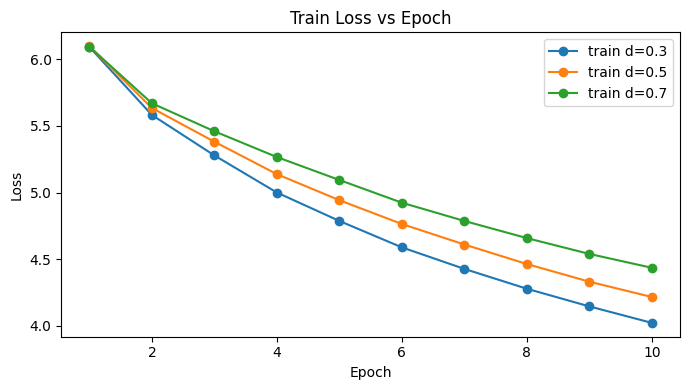

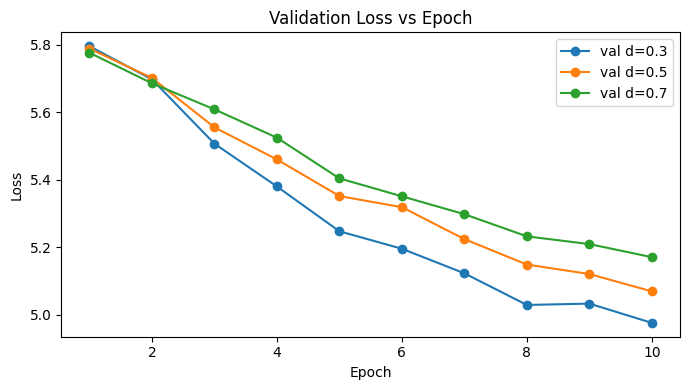

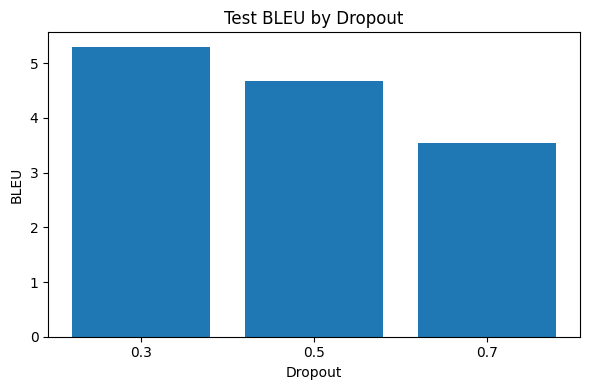

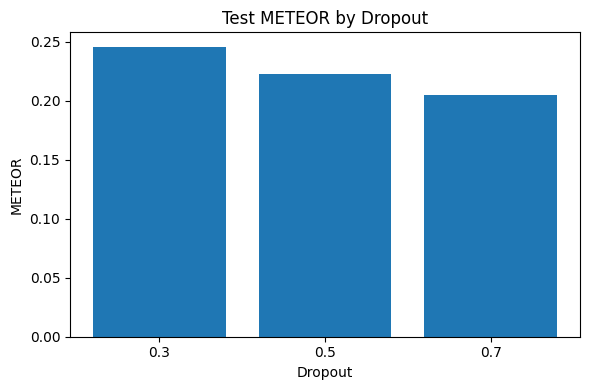

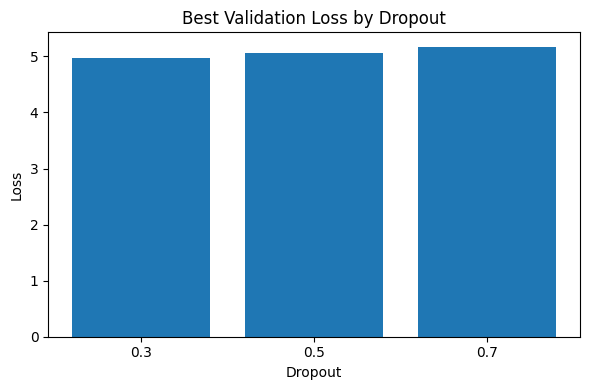

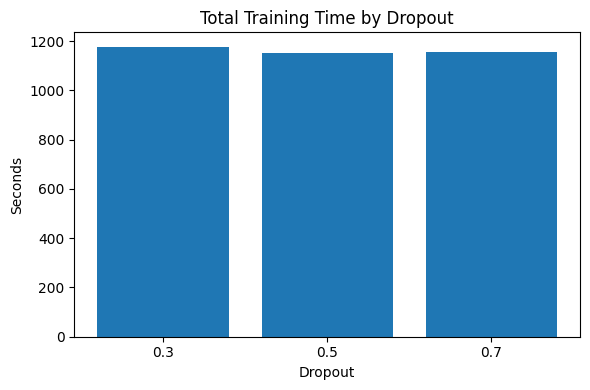

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

summary_df = pd.DataFrame(exp4_results).sort_values("dropout").reset_index(drop=True)
display(summary_df)

history_rows = []
for item in exp4_history:
    dval = item["dropout"]
    for row in item["history"]:
        history_rows.append({"dropout": dval, **row})
history_df = pd.DataFrame(history_rows)

# Line plots: train/val loss vs epoch
plt.figure(figsize=(7, 4))
for dval, grp in history_df.groupby("dropout"):
    plt.plot(grp["epoch"], grp["train_loss"], marker="o", label=f"train d={dval}")
plt.title("Train Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
for dval, grp in history_df.groupby("dropout"):
    plt.plot(grp["epoch"], grp["val_loss"], marker="o", label=f"val d={dval}")
plt.title("Validation Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

# Bar charts for final metrics
plt.figure(figsize=(6, 4))
plt.bar(summary_df["dropout"].astype(str), summary_df["bleu"])
plt.title("Test BLEU by Dropout")
plt.xlabel("Dropout")
plt.ylabel("BLEU")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(summary_df["dropout"].astype(str), summary_df["meteor"])
plt.title("Test METEOR by Dropout")
plt.xlabel("Dropout")
plt.ylabel("METEOR")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(summary_df["dropout"].astype(str), summary_df["best_val_loss"])
plt.title("Best Validation Loss by Dropout")
plt.xlabel("Dropout")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(summary_df["dropout"].astype(str), summary_df["total_time_sec"])
plt.title("Total Training Time by Dropout")
plt.xlabel("Dropout")
plt.ylabel("Seconds")
plt.tight_layout()
plt.show()